# Chlorophyll Fluorescence from a set of models


In [35]:
import numpy as np
import matplotlib.pyplot as plt
from importlib import reload

from ocpy.satellites import pace as sat_pace

from correct_atmosphere import downwelling

from bing.rt import chl_fl
from bing.rt import raman
from bing.rt import rrs
from bing.fitting import l23
from bing.parameters import standard
from bing.models import utils as model_utils
from bing import evaluate

#from bing.tests import test_chl_fl

%matplotlib inline

# Init a model

## Standard

In [2]:
p_expb = standard.expb_pow(satellite='SBG', add_noise=True,
                        variable_Gordon=False, include_Raman=False,
                         include_Chl_fl=True)
model_wave = sat_pace.wave(wv_min=p_expb.wv_min,
                                wv_max=p_expb.wv_max)                        
model_names=['ExpBricaud', 'Pow']
a_model, bb_model = model_utils.init(model_names, model_wave)

## Chl

In [3]:
Ed = downwelling.downwelling_irradiance(a_model.wave, 0.)
Ed_em = downwelling.downwelling_irradiance(chl_fl.LAMBDA_FL_PRIMARY, 0.)
a_model.init_Chl_fluorescence(Ed=Ed, Ed_em=Ed_em)

## Params

In [22]:
a_params = np.array([-1.6029689 ,  0.01230832, -2.3059037])
bb_params = np.array([-3.4574142 ,  1.085985])

# Calculate without

## RT dict

In [13]:
rt_dict = {}
rt_dict['variable_Gordon'] = True 
G1, G2 = rrs.wave_dependent_gordon(a_model.wave)
a_model.G1 = G1
a_model.G2 = G2
rt_dict['include_Raman'] = False
rt_dict['include_Chl_fl'] = False

In [14]:
Rrs = evaluate.calc_Rrs_from_models(a_model, aparam, bb_model, bparam, rt_dict)

## Plot

/tmp/ipykernel_33806/3027416821.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=10)


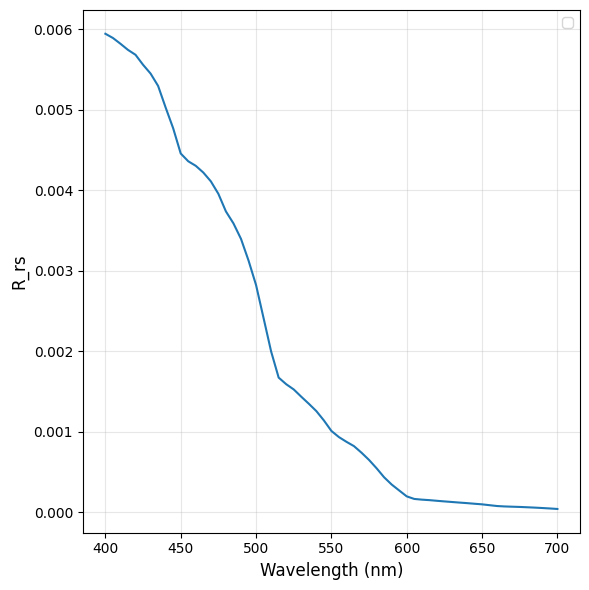

In [17]:
fig, ax = plt.subplots(figsize=(6, 6))

ax.plot(a_model.wave, Rrs.flatten())

#ax.invert_yaxis()
ax.set_xlabel('Wavelength (nm)', fontsize=12)
ax.set_ylabel('R_rs', fontsize=12)
#ax.set_title('Fluorescence Quantum Yield Depth Profile', fontsize=14)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# With

In [18]:
rt_dict2 = rt_dict.copy()
rt_dict2['include_Chl_fl'] = True

In [24]:
a_model.i_Chl_ex

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33,
       34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50,
       51, 52, 53, 54, 55, 56, 57, 58, 59, 60])

In [25]:
a.shape

(1, 61)

In [29]:
a_model.a_ph

array([0.54834392, 0.59593654, 0.66202407, 0.7291566 , 0.78822975,
       0.84788693, 0.90247074, 0.96204999, 1.        , 1.00985022,
       0.98845526, 0.96469694, 0.93471283, 0.90745045, 0.8780531 ,
       0.84751503, 0.8124549 , 0.76799856, 0.7028089 , 0.61923898,
       0.52070351, 0.42419093, 0.34003528, 0.27406284, 0.222295  ,
       0.18600811, 0.15799291, 0.13295263, 0.11454421, 0.10130767,
       0.08880864, 0.07655064, 0.07118835, 0.06611224, 0.06321866,
       0.06716208, 0.07046087, 0.0767814 , 0.08114952, 0.08288338,
       0.0820232 , 0.08171507, 0.08334613, 0.08579381, 0.08910553,
       0.09282732, 0.09852264, 0.10341072, 0.1091099 , 0.11931495,
       0.13007439, 0.1459328 , 0.17777889, 0.23504228, 0.29205333,
       0.30342132, 0.26031437, 0.16710235, 0.08782197, 0.04535959,
       0.02475987])

In [33]:
a = a_model.eval_a(a_params)
bb = bb_model.eval_bb(bb_params)
a_chl_ex = a[:,a_model.i_Chl_ex]
a_chl_em = a[:,a_model.i_Chl_em]
bb_chl_ex = bb[:,a_model.i_Chl_ex]
bb_chl_em = bb[:,a_model.i_Chl_em]
# a_ph
aph = (10**a_params[...,-1:]) * a_model.a_ph
aph_ex = a_ph[a_model.i_Chl_ex]

In [56]:
aph_ex

array([0.00271112, 0.00294643, 0.00327318, 0.0036051 , 0.00389717,
       0.00419213, 0.004462  , 0.00475657, 0.0049442 , 0.0049929 ,
       0.00488712, 0.00476966, 0.00462141, 0.00448662, 0.00434127,
       0.00419029, 0.00401694, 0.00379714, 0.00347483, 0.00306164,
       0.00257446, 0.00209729, 0.0016812 , 0.00135502, 0.00109907,
       0.00091966, 0.00078115, 0.00065734, 0.00056633, 0.00050089,
       0.00043909, 0.00037848, 0.00035197, 0.00032687, 0.00031257,
       0.00033206, 0.00034837, 0.00037962, 0.00040122, 0.00040979,
       0.00040554, 0.00040402, 0.00041208, 0.00042418, 0.00044056,
       0.00045896, 0.00048712, 0.00051128, 0.00053946, 0.00058992,
       0.00064311, 0.00072152, 0.00087897, 0.0011621 , 0.00144397,
       0.00150018, 0.00128705, 0.00082619, 0.00043421, 0.00022427,
       0.00012242])

In [58]:
reload(rrs)
Rrs_fl_em = rrs.calc_Rrs_fluorescence(a_model.wave[a_model.i_Chl_em],
                               a_chl_em,
                               bb_chl_em,
                               a_chl_ex,
                               bb_chl_ex,
                               aph_ex, 
                               a_model.wave[a_model.i_Chl_ex],
                               a_model.Ed_ex,
                               a_model.Ed_em)
Rrs_fl_em.shape

(1, 11)

In [59]:
Rrs_fl = np.zeros_like(Rrs)
Rrs_fl[...,a_model.i_Chl_em] = Rrs_fl_em

### Plot

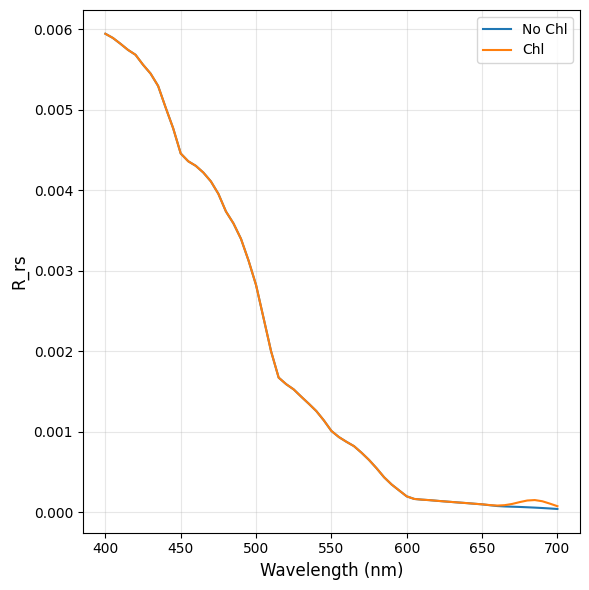

In [60]:
fig, ax = plt.subplots(figsize=(6, 6))

ax.plot(a_model.wave, Rrs.flatten(), label='No Chl')
ax.plot(a_model.wave, Rrs.flatten() + Rrs_fl.flatten(), label='Chl')

#ax.invert_yaxis()
ax.set_xlabel('Wavelength (nm)', fontsize=12)
ax.set_ylabel('R_rs', fontsize=12)
#ax.set_title('Fluorescence Quantum Yield Depth Profile', fontsize=14)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()